<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Document_Process_with_OCR_%26_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dcoument Processing with OCR

## 1. Installl and IMport Libararies

In [49]:
!pip install pytesseract langchain langchain-openai langchain-classic

In [50]:
from PIL import Image
import pytesseract
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor


## 2. Create OCR Tool

In [55]:
import base64

@tool
def ocr_read_document(image_path: str) -> str:
  """Read and image from the given path and return extracted text using OCR. """
  try:
    text = pytesseract.image_to_string(Image.open(image_path))
    return text
  except Exception as e:
    return f'Error reading image: {e}'


### 2.1 Use OCR to parse a document

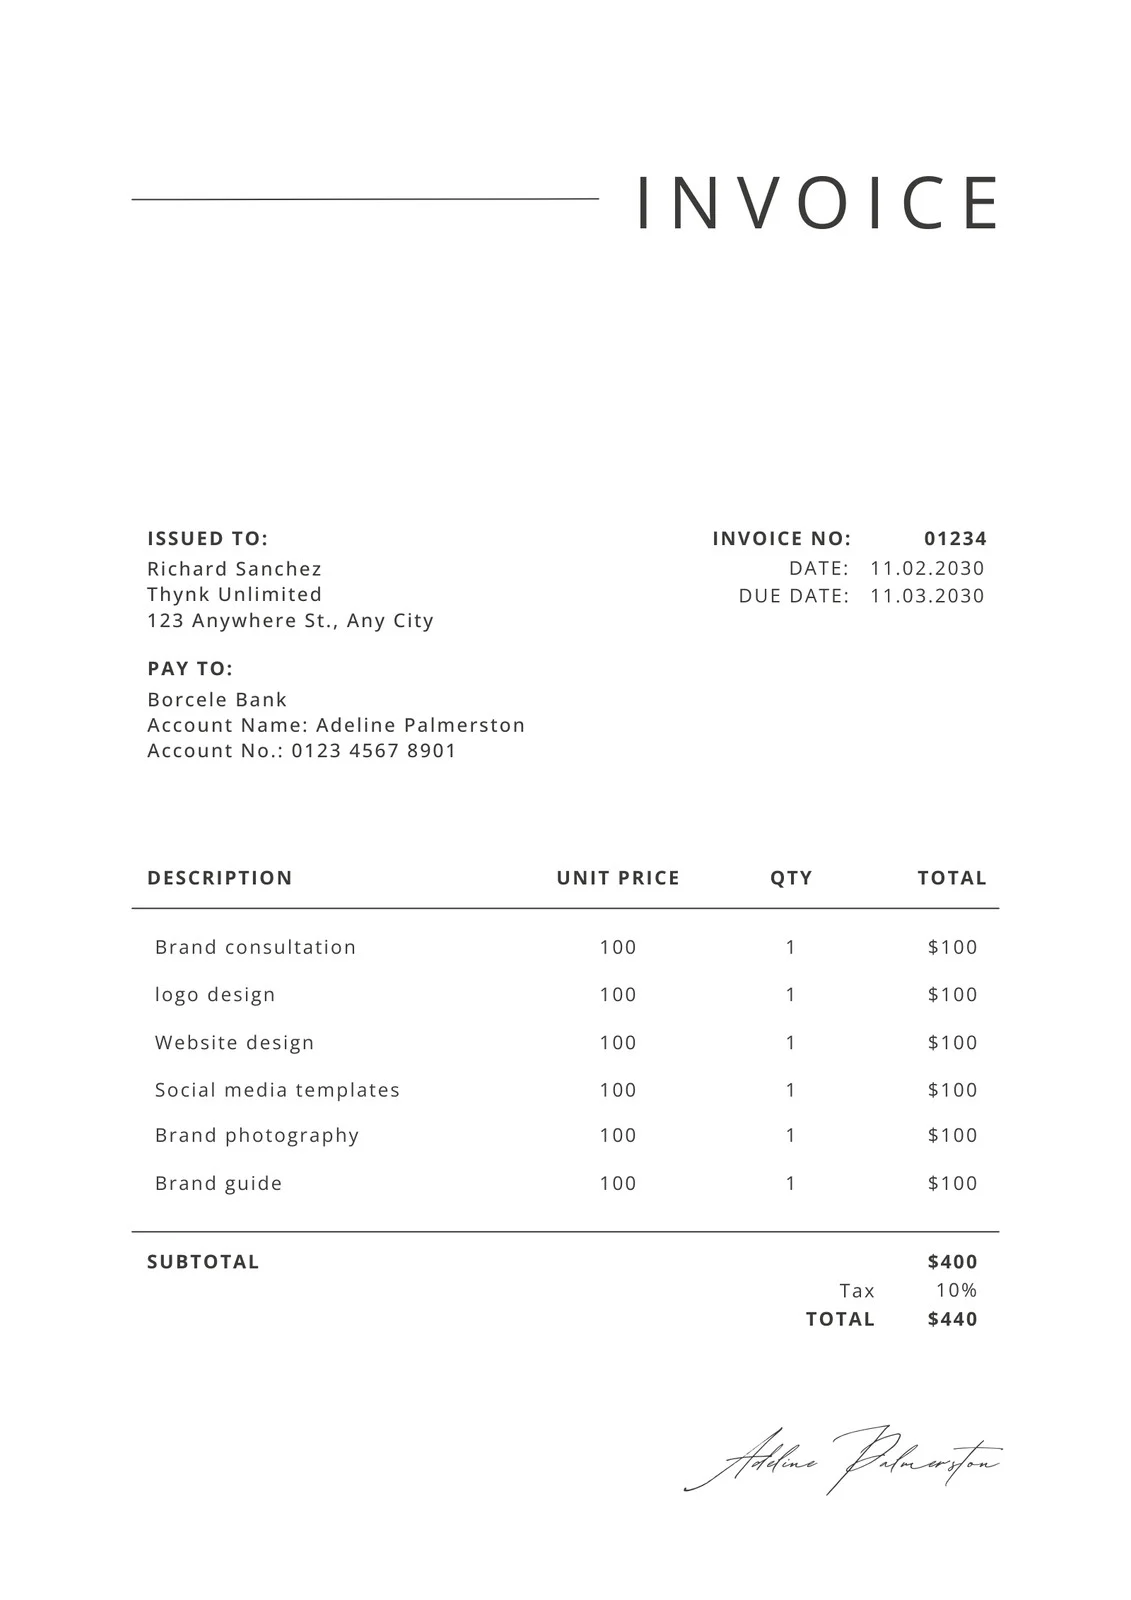

In [57]:
from IPython.display import display

image_path = 'invoice.webp'
img = Image.open(image_path)
display(img)

In [58]:
ocr_text = ocr_read_document.run('invoice.webp')
print("====== Raw OCR Output ======\n", ocr_text)

====== Raw OCR Output ======
 INVOICE

ISSUED TO: INVOICE NO: 01234
Richard Sanchez DATE: 11.02.2030
Thynk Unlimited DUE DATE: 11.03.2030

123 Anywhere St., Any City

PAY TO:

Borcele Bank

Account Name: Adeline Palmerston
Account No.: 0123 4567 8901

 

 

DESCRIPTION UNIT PRICE QTY TOTAL
Brand consultation 100 1 $100
logo design 100 1 $100
Website design 100 1 $100
Social media templates 100 1 $100
Brand photography 100 1 $100
Brand guide 100 1 $100
SUBTOTAL $400

Tax 10%

TOTAL $440

 



### 2.2 Use Regex to extract information

In [63]:
import re

# Regex to find Tax or Total followed by optional space and dolllar sign,
tax_match = re.search(r'Tax\s*\$?([0-9.,]+)', ocr_text)
total_mathch = re.search(r'TOTAL\s\$?([0-9.,]+)', ocr_text)

# print tax amount if found
if tax_match:
  print("Tax Found by Regex: ", tax_match.group(1))
else:
  print("Tax not found by regex.")

# print total amount if found
if total_mathch:
  print("Total found by regex: ", total_mathch.group(1))
else:
  print("Totlal not found by regex.")

Tax Found by Regex:  10
Total found by regex:  400


Two problem is here first `TOTAL` is capital so we must check in capital
second it got the subtotal instead of the total

**This is the problem with `OCR`**

## 3. Create the Agent

In [87]:
import os
from dotenv import load_dotenv
# Load environment variables from .env
_ = load_dotenv(override=True)

In [91]:
import os
# 1. Define the list of tools
tools = [ocr_read_document]

# 2. set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    llm = None
else:
    llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=1
    )
    print("OpenAI Chat model initialized.")

OpenAI Chat model initialized.


Now create the agent using the ReAct framework with the LLM, tools, and prompt. Then set up the `AgentExecutor` to run the agent loop.

In [92]:
from langchain_classic.agents import create_tool_calling_agent

# 3. Create the OpenAI-compatible prompt
prompt = ChatPromptTemplate.from_messages(
      [
          (
              "system",
              "You are a helpful assistant designed to extract information "
              +"from documents."
              "you have access to this tool: "
              "OCR tool to extract raw text from images "
          ),
          ("user", "{input}"),
          MessagesPlaceholder(variable_name='agent_scratchpad'),
      ]
)

# 4. Create a proper tool-calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

# 5. Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

## 4. Run the Agent and extract information

In [93]:
task = """
Please process the document at 'invoice.png' using the OCR tool
and extract the following information in JSON format:
- tax
- total
"""

# Use .invoke() with a dictionary input for the agent_executor
response = agent_executor.invoke({"input": task})



> Entering new AgentExecutor chain...


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}